# Assignment 6 — Generation Experiment
**DATAX504 | Modality: text**

## Aim
Can a small character-level GRU learn the format of dialogue, and how does sampling temperature change its output?

I use a small part of the Tiny Shakespeare dataset. The model predicts the next character from earlier characters. I compare five temperatures using the same starting text and random seed. This is a small learning experiment, so I do not expect it to write a complete or meaningful play.

The notebook includes training outputs, five unedited samples, a failure analysis, and the required AR versus diffusion reflection.

## AI disclosure (required)

| Field | Your answer |
|-------|-------------|
| Tool / model | ChatGPT / Codex (GPT-6). |
| Used for | Help with experiment design, Python code, debugging, source checking, and drafting the failure analysis and reflection in simple English. |
| Verified how | The notebook was executed from top to bottom in a fresh Python session. The data split, saved outputs, five generated samples, and reflection sources were checked with AI assistance. |
| Not used for | Replacing model output with AI-written samples, inventing training results, or claiming that an AR-versus-diffusion benchmark was run. The five samples are unedited outputs from the trained GRU. |

## 1. Setup
The experiment uses Keras 3 with its JAX backend on CPU. There is no pretrained language model or paid API. Install the packages in `requirements.txt` if needed, then restart the kernel and use **Run All**. The saved outputs can also be read without rerunning the training.

In [1]:
# Optional one-time installation in a new notebook environment:
# %pip install keras==3.15.1 jax==0.11.2 numpy matplotlib
# Restart the kernel after installation.

import os
# This setting must come before importing Keras.
os.environ["KERAS_BACKEND"] = "jax"
os.environ["JAX_PLATFORMS"] = "cpu"

from pathlib import Path
import hashlib
import json
import platform
import time
import urllib.request

import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers

MODALITY = "text"
SEED = 42
keras.utils.set_random_seed(SEED)

print("Selected modality:", MODALITY)
print("Python:", platform.python_version())
print("Keras:", keras.__version__, "| Backend:", keras.backend.backend())

Selected modality: text
Python: 3.12.14
Keras: 3.15.1 | Backend: jax


## 2. Data source and preprocessing
**Source:** Tiny Shakespeare, distributed in Andrej Karpathy's `char-rnn` repository:  
https://github.com/karpathy/char-rnn/blob/master/data/tinyshakespeare/input.txt

The underlying texts are Shakespeare plays. This is a public literary dataset, not AI-generated training text. I use only the first **200,000 characters**, convert them to lowercase, and keep spaces, punctuation, and line breaks. This reduces the vocabulary while preserving dialogue formatting. The full source file has SHA-256 `86c4e6aa9db7c042ec79f339dcb96d42b0075e16b8fc2e86bf0ca57e2dc565ed`.

I split the text into the first **80% for training** and the last **20% for validation before creating windows**. This keeps overlapping windows from crossing the split. Validation is used to choose the training checkpoint; it is not an independent test set. The vocabulary is built from the training portion only.

Each input contains **64 characters**, and its target is the same sequence shifted forward by one character. Windows start every **16 characters**. The model therefore receives many next-character examples while the dataset stays small.

In [2]:
DATA_URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
EXPECTED_SHA256 = "86c4e6aa9db7c042ec79f339dcb96d42b0075e16b8fc2e86bf0ca57e2dc565ed"
data_path = Path("data/tinyshakespeare.txt")
data_path.parent.mkdir(parents=True, exist_ok=True)

# Use the included data file; download it only if it is missing.
if not data_path.exists():
    with urllib.request.urlopen(DATA_URL, timeout=60) as response:
        data_path.write_bytes(response.read())
raw_bytes = data_path.read_bytes()
assert hashlib.sha256(raw_bytes).hexdigest() == EXPECTED_SHA256, "Unexpected dataset file."
raw_text = raw_bytes.decode("utf-8")
text = raw_text[:200_000].lower()
split_at = int(0.8 * len(text))
train_text, val_text = text[:split_at], text[split_at:]

chars = sorted(set(train_text))
char_to_id = {ch: i for i, ch in enumerate(chars)}
vocab_size = len(chars)
assert set(val_text).issubset(char_to_id), "Validation contains an unknown character."

SEQ_LEN = 64
STRIDE = 16

def make_windows(part):
    ids = np.array([char_to_id[ch] for ch in part], dtype=np.int32)
    starts = range(0, len(ids) - SEQ_LEN, STRIDE)
    x = np.stack([ids[i:i + SEQ_LEN] for i in starts])
    y = np.stack([ids[i + 1:i + SEQ_LEN + 1] for i in starts])
    return x, y

x_train, y_train = make_windows(train_text)
x_val, y_val = make_windows(val_text)
assert x_train.shape == y_train.shape and x_val.shape == y_val.shape
assert np.array_equal(x_train[0, 1:], y_train[0, :-1])

print("Full source characters:", len(raw_text))
print("Used characters:", len(text))
print("Training / validation characters:", len(train_text), "/", len(val_text))
print("Vocabulary size:", vocab_size)
print("Training windows:", x_train.shape, "| Validation windows:", x_val.shape)
print("Training excerpt:", repr(train_text[:120]))

Full source characters: 1115394
Used characters: 200000
Training / validation characters: 160000 / 40000
Vocabulary size: 37
Training windows: (9996, 64) | Validation windows: (2496, 64)
Training excerpt: 'first citizen:\nbefore we proceed any further, hear me speak.\n\nall:\nspeak, speak.\n\nfirst citizen:\nyou are all resolved ra'


## 3. Model and training plan
The model has a **32-dimensional character embedding**, one **96-unit GRU**, and a dense output layer. The GRU returns a prediction at every position. The output is a set of character logits; sparse categorical cross-entropy measures how well the next-character predictions match the text.

I train for at most **20 epochs**, with **batch size 64** and **Adam at learning rate 0.003**. Gradient clipping at a global norm of 1.0 helps keep training stable. Early stopping uses validation loss with patience 3, and restores the best weights. A fixed seed makes the setup easier to reproduce, although results may vary slightly with software or hardware.

In [3]:
model = keras.Sequential([
    keras.Input(shape=(None,), dtype="int32"),
    layers.Embedding(vocab_size, 32),
    layers.GRU(96, return_sequences=True),
    layers.Dense(vocab_size),  # Logits for the next character.
])
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.003, global_clipnorm=1.0),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
)
model.summary()

# A simple reference: assigning equal probability to every character.
uniform_ce = float(np.log(vocab_size))
initial_val_ce = float(model.evaluate(x_val, y_val, batch_size=64, verbose=0))
print(f"Uniform character baseline CE: {uniform_ce:.4f}")
print(f"Untrained model validation CE: {initial_val_ce:.4f}")

Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, None, 32)       │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, None, 96)       │        37,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 37)       │         3,589 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 42,213 (164.89 KB)
 Trainable params: 42,213 (164.89 KB)
 Non-trainable params: 0 (0.00 B)
Uniform character baseline CE: 3.6109
Untrained model validation CE: 3.6103


In [4]:
start_time = time.perf_counter()
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    batch_size=64,
    epochs=20,
    shuffle=True,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=3, restore_best_weights=True
    )],
    verbose=2,
)
training_seconds = time.perf_counter() - start_time
final_val_ce = float(model.evaluate(x_val, y_val, batch_size=64, verbose=0))
best_epoch = int(np.argmin(history.history["val_loss"]) + 1)

metrics = {
    "seed": SEED,
    "parameters": model.count_params(),
    "epochs_completed": len(history.history["loss"]),
    "best_epoch": best_epoch,
    "training_seconds": training_seconds,
    "uniform_baseline_ce": uniform_ce,
    "untrained_validation_ce": initial_val_ce,
    "final_validation_ce": final_val_ce,
    "validation_character_perplexity": float(np.exp(final_val_ce)),
    "history": {key: [float(v) for v in values] for key, values in history.history.items()},
}
print(f"Training time on this CPU: {training_seconds:.1f} seconds")
print(f"Best checkpoint: epoch {best_epoch}")
print(f"Final validation CE: {final_val_ce:.4f}")
print(f"Validation character perplexity: {np.exp(final_val_ce):.2f}")

Epoch 1/20
157/157 - 4s - 25ms/step - loss: 2.5694 - val_loss: 2.2480
Epoch 2/20
157/157 - 3s - 20ms/step - loss: 1.9652 - val_loss: 2.0270
Epoch 3/20
157/157 - 3s - 21ms/step - loss: 1.7344 - val_loss: 1.9302
Epoch 4/20
157/157 - 3s - 22ms/step - loss: 1.6238 - val_loss: 1.8712
Epoch 5/20
157/157 - 4s - 24ms/step - loss: 1.5566 - val_loss: 1.8533
Epoch 6/20
157/157 - 3s - 22ms/step - loss: 1.5108 - val_loss: 1.8461
Epoch 7/20
157/157 - 4s - 25ms/step - loss: 1.4776 - val_loss: 1.8398
Epoch 8/20
157/157 - 4s - 24ms/step - loss: 1.4519 - val_loss: 1.8307
Epoch 9/20
157/157 - 3s - 21ms/step - loss: 1.4302 - val_loss: 1.8392
Epoch 10/20
157/157 - 3s - 20ms/step - loss: 1.4120 - val_loss: 1.8422
Epoch 11/20
157/157 - 3s - 20ms/step - loss: 1.3975 - val_loss: 1.8492
Training time on this CPU: 38.3 seconds
Best checkpoint: epoch 8
Final validation CE: 1.8307
Validation character perplexity: 6.24


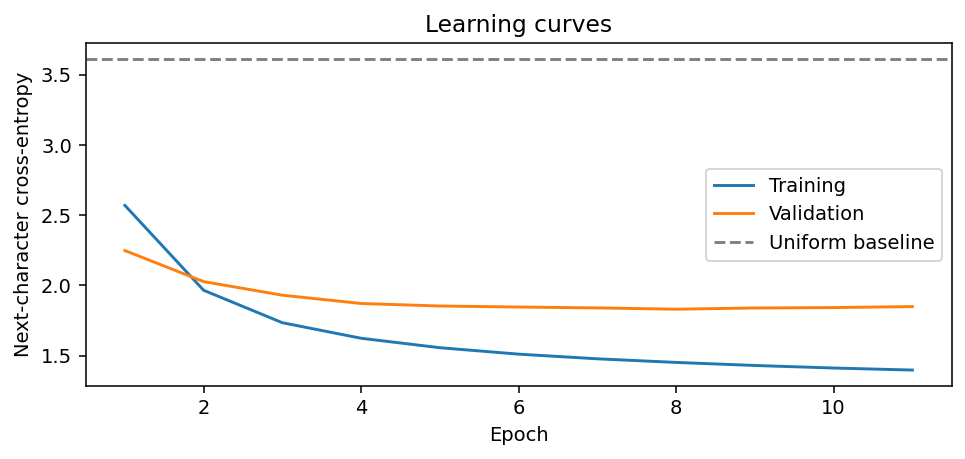

In [5]:
epochs = np.arange(1, len(history.history["loss"]) + 1)
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(epochs, history.history["loss"], label="Training")
ax.plot(epochs, history.history["val_loss"], label="Validation")
ax.axhline(uniform_ce, linestyle="--", color="grey", label="Uniform baseline")
ax.set(xlabel="Epoch", ylabel="Next-character cross-entropy", title="Learning curves")
ax.legend()
fig.tight_layout()
plt.show()

## Training result
The model has **42,213 trainable parameters**. Training stopped after **11 epochs** and restored the best checkpoint from **epoch 8**. It took **38.3 seconds** on the CPU used here; a different laptop may take longer.

Validation next-character cross-entropy fell from **3.6103** before training to **1.8307**, compared with **3.6109** for equal character probabilities. Character perplexity was **6.24**. These results show better next-character prediction than the uniform baseline, not good sentence meaning. Training loss continued to fall after the best validation epoch, suggesting overfitting. The five generated samples below provide a separate qualitative check.

## 4. Five generated samples
All five samples use the prompt **`first citizen:\n`**, a sampling seed of **2026**, and **200 new characters**. The prompt is shown separately and is not counted as generated output. I display every result from the five settings below, without choosing the best examples or editing their spelling.

At each step, the last 64 characters are passed to the model. I divide the predicted logits by the temperature, apply softmax, and sample one character. Lower temperatures favour more likely characters; higher temperatures make the choices more varied. Holding the prompt and seed fixed helps inspect the effect of temperature, but five short samples are not a full quality benchmark.

In [6]:
PROMPT = "first citizen:\n"
TEMPERATURES = [0.4, 0.7, 0.9, 1.1, 1.3]
NEW_CHARACTERS = 200
SAMPLING_SEED = 2026

# Compile inference for a fixed 64-character context, including shorter prompts.
# Leading positions are masked so padding does not become artificial context.
# This separate inference model shares the trained layers and weights.
inference_input = keras.Input(shape=(SEQ_LEN,), dtype="int32")
embedded = model.layers[0](inference_input)
mask_input = keras.Input(shape=(SEQ_LEN,), dtype="bool")
hidden = model.layers[1](embedded, mask=mask_input)
logits_output = model.layers[2](hidden)
inference_model = keras.Model([inference_input, mask_input], logits_output)
inference_model.compile()

def generate_text(temperature, seed=SAMPLING_SEED):
    rng = np.random.default_rng(seed)
    context = [char_to_id[ch] for ch in PROMPT]
    output = []
    for _ in range(NEW_CHARACTERS):
        recent = context[-SEQ_LEN:]
        padded = np.zeros((1, SEQ_LEN), dtype=np.int32)
        mask = np.zeros((1, SEQ_LEN), dtype=bool)
        padded[0, -len(recent):] = recent
        mask[0, -len(recent):] = True
        logits = inference_model.predict([padded, mask], verbose=0)[0, -1]
        scaled = np.asarray(logits, dtype=np.float64) / temperature
        scaled -= scaled.max()  # Stable softmax.
        probabilities = np.exp(scaled)
        probabilities /= probabilities.sum()
        next_id = int(rng.choice(vocab_size, p=probabilities))
        context.append(next_id)
        output.append(chars[next_id])
    return "".join(output)

samples = []
for i, temperature in enumerate(TEMPERATURES, start=1):
    generated = generate_text(temperature)
    samples.append({"sample": i, "temperature": temperature,
                    "prompt": PROMPT, "seed": SAMPLING_SEED, "continuation": generated})
    print(f"Sample {i} | temperature={temperature} | seed={SAMPLING_SEED}")
    print("Prompt:", repr(PROMPT))
    print("Generated continuation:")
    print(generated)
    print("-" * 60)

assert len(samples) == 5
assert all(len(s["continuation"]) == NEW_CHARACTERS for s in samples)

Sample 1 | temperature=0.4 | seed=2026
Prompt: 'first citizen:\n'
Generated continuation:
and the senators, and the common men of the common a prove
the could he would be than the virtue the common me so has dispose the wind to the consul my son, i that have made unto the wars the people a
------------------------------------------------------------
Sample 2 | temperature=0.7 | seed=2026
Prompt: 'first citizen:\n'
Generated continuation:
and my fortune, for the lies if your honourd porter in the
then traitor, you take reasons.

volumnia:
o, and not be ambles, carries to the shopes,
i have rather should
be good the rest state of this f
------------------------------------------------------------
Sample 3 | temperature=0.9 | seed=2026
Prompt: 'first citizen:\n'
Generated continuation:
and is fortune, he end,
i graind's winong in my son, must 'tis but it only set mear and roves. thou should thee the common he our worthy son:
for do it off up'tines,
year intrevated, you are solding m
-----

## 5. Failure mode (Moodle `a6_failure`)
**Main failure mode: incoherent text.**

The model learns some real words and dialogue layout, but it does not keep a clear meaning across a sentence. For example, sample 1 contains “the common a prove”, and sample 3 contains “i graind's winong”. Sample 2 even creates a speaker label, “volumnia:”, but the surrounding sentences are still unclear.

| Sample | Temperature | What I notice |
|---|---:|---|
| 1 | 0.4 | More common words, but “the common” is repeated and the sentence loses meaning. |
| 2 | 0.7 | A dialogue label and recognisable phrases appear, but “honourd” and “shopes” are malformed. |
| 3 | 0.9 | Some familiar words are mixed with unclear phrases and invented spellings such as “winong”. |
| 4 | 1.1 | More spelling errors, including “emep” and “neft”, make the text harder to read. |
| 5 | 1.3 | The text is more varied, but invented strings such as “meectly” and “istricuak” reduce readability. |

These five samples suggest a trade-off between variety and readability. Lowering the temperature helps spelling but does not solve the lack of meaning. The small training subset, model size, and 64-character context are possible reasons; this experiment does not separate their effects. Longer training alone is unlikely to be enough because validation loss already stopped improving. A useful next experiment would add more training text while keeping a separate validation section, then check longer outputs at several seeds.

## 6. AR vs diffusion reflection (Moodle `a6_diffusion_reflection`)

My GRU generates text autoregressively: each character depends on the earlier text. This is simple to train and allows control through a starting prompt and temperature. However, a wrong choice can affect later characters. My samples learn dialogue formatting but lose meaning, while higher temperatures produce more spelling errors. The Hugging Face reading describes diffusion as refining noisy or masked text through several steps (ProCreations, 2025). Masked diffusion models can use context on both sides when filling gaps, which may offer better control over editing (Nie et al., 2025). However, repeated denoising requires several model calls. Predicting multiple positions together therefore does not guarantee faster generation or lower compute. Hardware also matters. Diffusion can still produce incoherent text, and quality depends on the data, model size, and sampling steps. AR was practical for this small laptop experiment. I did not train diffusion, so these trade-offs are conceptual rather than measured.

*Word count: 150 (including in-text citations).*

## 7. References

- Karpathy, A. (n.d.). *Tiny Shakespeare* [Data set]. GitHub. https://github.com/karpathy/char-rnn/blob/master/data/tinyshakespeare/input.txt
- Chollet, F. (2020, April 30). *Character-level text generation with LSTM*. Keras. https://keras.io/examples/generative/lstm_character_level_text_generation/ (Background for next-character modelling and temperature sampling; this experiment uses a GRU and integer embeddings instead.)
- ProCreations. (2025, June 10). *Diffusion language models: The new paradigm*. Hugging Face. https://huggingface.co/blog/ProCreations/diffusion-language-model
- Nie, S., Zhu, F., You, Z., Zhang, X., Ou, J., Hu, J., Zhou, J., Lin, Y., Wen, J.-R., & Li, C. (2025). *Large language diffusion models* [Preprint]. arXiv. https://doi.org/10.48550/arXiv.2502.09992

In [7]:
# Save actual model weights and results for inspection or reuse.
artifact_dir = Path("artifacts")
artifact_dir.mkdir(exist_ok=True)
model.save(artifact_dir / "char_gru.keras")
(artifact_dir / "training_metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")
(artifact_dir / "five_samples.json").write_text(json.dumps(samples, indent=2), encoding="utf-8")
print("Saved: artifacts/char_gru.keras, training_metrics.json, and five_samples.json")

Saved: artifacts/char_gru.keras, training_metrics.json, and five_samples.json
